# Generative v0 — synthetic `u(t)` → replay → trajectory distributions

**Goal:** compare pools of trajectories, not extracted vs generated commands on the same flight.

| Pool | What it is |
|------|------------|
| **Operational reference** | Replay **extracted** commands → `gen_altitude_ft`, `gen_tas_kt`, … (fleet envelope) |
| **Synthetic** | Draw **new** `u(t)` from empirical laws (like model inference) → replay → same state variables |

Compare pooled ECDFs / φ-profiles / W1 between the two trajectory ensembles.

## v0 command rules

**Conditioning truth:** `GC_NM` + `TYPECODE`

| | Sampling / assembly | Validation vs ops |
|--|--|--|
| Label | `gc_nm=… \| seed=…` | Ops flights keep `route`/`flight_id`; synthetic pool sized to compare envelopes |
| Laws | Pooled by `gc_nm` bin + typecode family | Same laws; ops = replay extracted cmds |

**Law fit:** accepted flights on routes within `GC_NM ± GC_NM_ATOL_NM`.


In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

PKG_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PKG_ROOT))

from pipeline.opendata import list_routes, accepted_command_flight_ids, route_gc_nm
from pipeline.replay import rollout_vertical_dynamics, replay_metrics
from pipeline.logic import fit_empirical_laws, make_sample_context, select_conditioning, load_flight_metadata_table
from pipeline.generator import (
    compare_trajectory_pools,
    generate_commands,
    run_operational_trajectory_pool,
    run_synthetic_trajectory_pool,
)
from pipeline.sampling import V0_RULES, load_flight_template
from scipy import stats as sp_stats

print(V0_RULES)

{'sampling': 'event-first (segment tables like extraction)', 'toc': 'outcome from vz_sel + max(h_sel), not sampled', 'tod': 'gc_nm-bin empirical phi_d → time via synthetic TAS integration', 'mach': 'φ_up / φ_dn spatial anchors → Mach plateau; crossover ft from profile'}


## CONFIG

In [3]:
ROUTES_ALL = [r for r in list_routes() if r.startswith('LSZH_')]

# --- conditioning ---
TYPECODE = 'A320'          # ICAO typecode, e.g. A320, B738, A20N
GC_NM = 480.0              # required: sector length [nm] for sampling, phi_d, and labels
GC_NM_ATOL_NM = 150.0      # routes kept if |route_gc_nm - GC_NM| <= this (law fit + ops only)
N_OPS_REFERENCE = 30       # minimum matching ops flights required (warn if fewer)
N_SYNTHETIC_DRAWS = 100    # synthetic u(t) / trajectory pool size (gc_nm + seed only)
BASE_SEED = 2026           # draw i uses seed BASE_SEED + i

if GC_NM is None:
    raise ValueError('Set GC_NM (e.g. 480). Synthetic draws are conditioned on gc_nm, not route id.')

OPS_REPLAY_KW = dict(tau_vz_s=0.0, start_phase='CLIMB', apply_vz_fill=True)
SYNTH_REPLAY_KW = dict(tau_vz_s=0.0, start_phase='CLIMB', apply_vz_fill=False)

selection = select_conditioning(
    ROUTES_ALL,
    typecode=TYPECODE,
    gc_nm=GC_NM,
    gc_nm_atol_nm=GC_NM_ATOL_NM,
    min_ops_flights=N_OPS_REFERENCE,
)
ROUTES = selection.routes
print('Typecode', TYPECODE, 'family', selection.family, '| GC_NM', GC_NM, 'nm')
print('Routes in band (ops + laws):', ROUTES)
print('Operational flights for reference pool:', selection.n_flights)
print(selection.flights.groupby('route').size())
print('Synthetic draws (generation):', N_SYNTHETIC_DRAWS, '@ gc_nm=', GC_NM)
print('Available typecodes (fleet):', sorted(load_flight_metadata_table(ROUTES_ALL)['typecode'].dropna().unique()))

Typecode A320 family A320 family | GC_NM 480.0 nm
Routes in band (ops + laws): ['LSZH_EGLL', 'LSZH_LEBL']
Operational flights for reference pool: 62
route
LSZH_EGLL    23
LSZH_LEBL    39
dtype: int64
Synthetic draws (generation): 100 @ gc_nm= 480.0
Available typecodes (fleet): ['A20N', 'A21N', 'A319', 'A320', 'A321', 'B737', 'B738', 'B739', 'BCS1', 'BCS3', 'C510', 'C56X', 'C680', 'E190', 'E290', 'E295', 'E55P', 'E75L', 'GL6T', 'None']


## Fit laws

In [4]:
laws = fit_empirical_laws(ROUTES, conditioning=selection)
print(len(laws.phase_laws), 'phase-law keys; gc_nm edges:', laws.gc_nm_edges)
print('mach_spatial (φ laws):', len(laws.mach_spatial), 'flights')

14 phase-law keys; gc_nm edges: [424.67000552 437.83044275 449.99087999 463.15131722]
mach_spatial (φ laws): 62 flights


## Single synthetic `u(t)` (φ assembly check)

In [5]:
ctx0 = make_sample_context(gc_nm=GC_NM, typecode=TYPECODE, seed=BASE_SEED, laws=laws)
cmds0, meta0 = generate_commands(laws, ctx0)
print('assembly', meta0.get('assembly'))
print('φ_up', round(meta0['phi_up'], 3), 'φ_tod', round(meta0['phi_d'], 3), 'φ_dn', round(meta0['phi_dn'], 3))
print('n_mach', meta0['n_mach'], '| pre-TOD end Mach', meta0['phi_dn'] < meta0['phi_d'])
print('mach_sel s', int(pd.to_numeric(cmds0['mach_sel'], errors='coerce').notna().sum()))
print('Hx ft', int(meta0['crossover_alt_ft_up']), '→', int(meta0['crossover_alt_ft_down']))
rep0 = rollout_vertical_dynamics(
    cmds0,
    crossover_alt_ft_up=meta0['crossover_alt_ft_up'],
    crossover_alt_ft_down=meta0['crossover_alt_ft_down'],
    **SYNTH_REPLAY_KW,
)
print('replay MAE ft', replay_metrics(rep0).get('mae_ft'))

assembly event_first_phi_v1
φ_up 0.127 φ_tod 0.685 φ_dn 0.71
n_mach 1 | pre-TOD end Mach False
mach_sel s 3107
Hx ft 23761 → 31866
replay MAE ft 58.33333333333563


## Replay floor (operational cmds vs ADS-B)

In [6]:
rows = []
for route in ROUTES[:1]:
    for fid in accepted_command_flight_ids(route)[:10]:
        tpl = load_flight_template(route, fid)
        rep = rollout_vertical_dynamics(tpl, **OPS_REPLAY_KW)
        rows.append({'route': route, 'flight_id': fid, **replay_metrics(rep)})
pd.DataFrame(rows)[['mae_ft', 'rmse_ft', 'bias_ft']].median()

mae_ft     603.280754
rmse_ft    617.670992
bias_ft   -408.845825
dtype: float64

## Validation: trajectory pools + pooled W1

Compare operational replays vs synthetic pool at fixed `GC_NM`.

In [7]:
operational_prof = run_operational_trajectory_pool(
    ROUTES,
    laws,
    conditioning=selection,
    replay_kw=OPS_REPLAY_KW,
    profile_source='replay',
)
synthetic_prof = run_synthetic_trajectory_pool(
    laws,
    conditioning=selection,
    gc_nm=GC_NM,
    n_draws=N_SYNTHETIC_DRAWS,
    base_seed=BASE_SEED,
    replay_kw=SYNTH_REPLAY_KW,
)
dist_met = compare_trajectory_pools(operational_prof, synthetic_prof)
print('rows:', len(operational_prof), 'ops |', len(synthetic_prof), 'synthetic')
dist_met.set_index('phase')[['w1_h_ft', 'w1_gamma_deg', 'w1_tas_kt', 'w1_vz_fpm']].round(1)

rows: 328218 ops | 515607 synthetic


,w1_h_ft,w1_gamma_deg,w1_tas_kt,w1_vz_fpm
phase,,,,
ALL,1939.6,0.2,6.1,120.5
CLIMB,1065.2,0.1,12.2,35.3
DESCENT,2396.4,0.1,8.3,59.7
LEVEL,3129.8,0.0,17.3,16.7


## Generation: browse assembled u(t)

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

from scripts.plot_full_u_timeline import plot_assembled_u

SYNTH_DRAW_SEEDS = [BASE_SEED + i for i in range(N_SYNTHETIC_DRAWS)]
print(len(SYNTH_DRAW_SEEDS), 'assembled u(t) at gc_nm', GC_NM, 'nm')

U_INDEX = 0
u_out = widgets.Output()
u_prev = widgets.Button(description='← Prev')
u_next = widgets.Button(description='Next →')
u_label = widgets.HTML()


def render_u():
    global U_INDEX
    with u_out:
        clear_output(wait=True)
        seed = SYNTH_DRAW_SEEDS[U_INDEX]
        ctx = make_sample_context(gc_nm=GC_NM, typecode=TYPECODE, seed=seed, laws=laws)
        u, meta = generate_commands(laws, ctx)
        lbl = f"{U_INDEX + 1}/{len(SYNTH_DRAW_SEEDS)} | gc_nm={GC_NM:.0f} nm | seed={seed}"
        u_label.value = f'<b>{lbl}</b>'
        print(
            'φ_up', round(meta.get('phi_up', 0), 3),
            'φ_tod', round(meta.get('phi_d', 0), 3),
            'φ_dn', round(meta.get('phi_dn', 0), 3),
            '| mach', int(pd.to_numeric(u['mach_sel'], errors='coerce').notna().sum()), 's',
            '| LEVEL', int((u['phase'].astype(str).str.upper() == 'LEVEL').sum()), 's',
        )
        title = (
            f"{lbl}  φ_up={meta.get('phi_up', float('nan')):.2f}"
            f" φ_tod={meta.get('phi_d', float('nan')):.2f}"
            f" φ_dn={meta.get('phi_dn', float('nan')):.2f}"
        )
        fig = plot_assembled_u(u, meta, title=title)
        display(fig)
        plt.close(fig)


def u_go_prev(_):
    global U_INDEX
    U_INDEX = (U_INDEX - 1) % len(SYNTH_DRAW_SEEDS)
    render_u()


def u_go_next(_):
    global U_INDEX
    U_INDEX = (U_INDEX + 1) % len(SYNTH_DRAW_SEEDS)
    render_u()


u_prev.on_click(u_go_prev)
u_next.on_click(u_go_next)
display(widgets.HBox([u_prev, u_next, u_label]))
display(u_out)
render_u()

100 assembled u(t) at gc_nm 480.0 nm


Output()

## ECDFs: operational vs synthetic trajectories

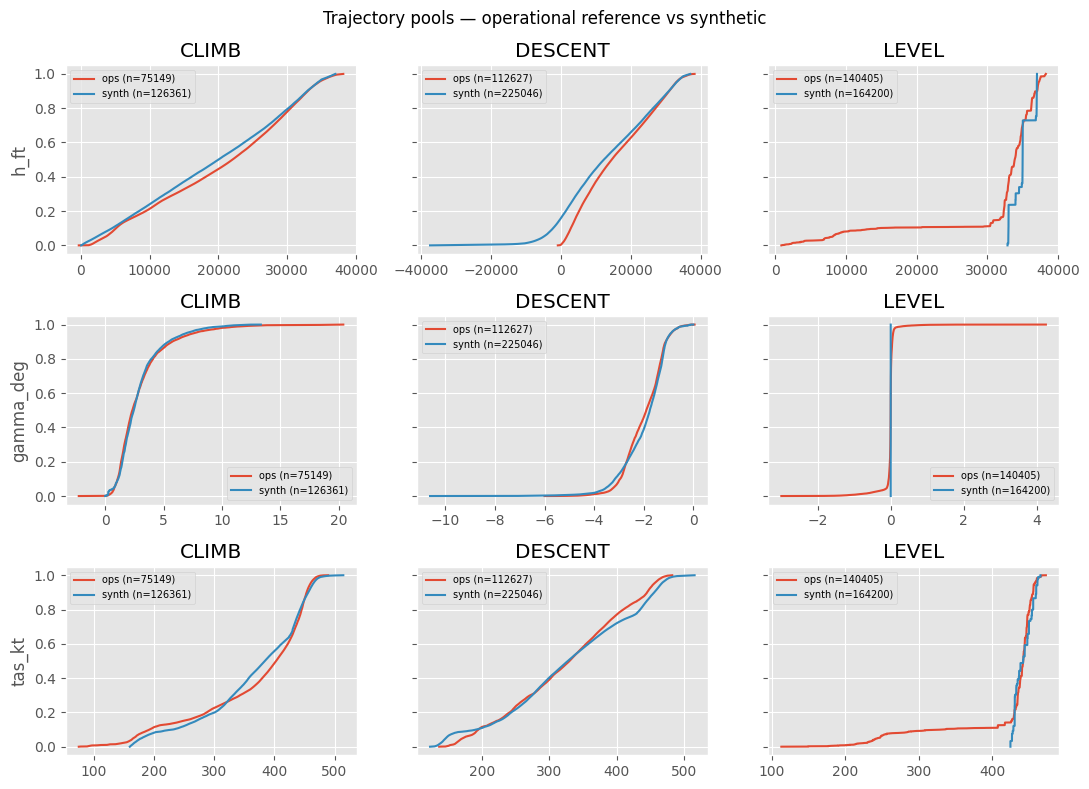

In [9]:
def plot_ecdf_pools(ref, syn, col, phase, ax):
    m = ref['phase'] == phase
    n = syn['phase'] == phase
    a = np.sort(ref.loc[m, col].dropna())
    b = np.sort(syn.loc[n, col].dropna())
    if len(a) < 10 or len(b) < 10:
        ax.set_title(f'{phase}: sparse')
        return
    ax.plot(a, np.arange(1, len(a) + 1) / len(a), label=f'ops (n={len(a)})', lw=1.5)
    ax.plot(b, np.arange(1, len(b) + 1) / len(b), label=f'synth (n={len(b)})', lw=1.5)
    ax.set_title(phase)
    ax.legend(fontsize=7)

phases, cols = ['CLIMB', 'DESCENT', 'LEVEL'], ['h_ft', 'gamma_deg', 'tas_kt']
fig, axes = plt.subplots(len(cols), len(phases), figsize=(11, 8), sharey='row')
for i, col in enumerate(cols):
    for j, ph in enumerate(phases):
        plot_ecdf_pools(operational_prof, synthetic_prof, col, ph, axes[i, j])
        if j == 0:
            axes[i, j].set_ylabel(col)
fig.suptitle('Trajectory pools — operational reference vs synthetic')
fig.tight_layout()
plt.show()

## φ-bands: altitude & vertical speed vs normalized time

Pooled **p10–p90** (shaded) and **median** lines by φ within CLIMB/DESCENT.

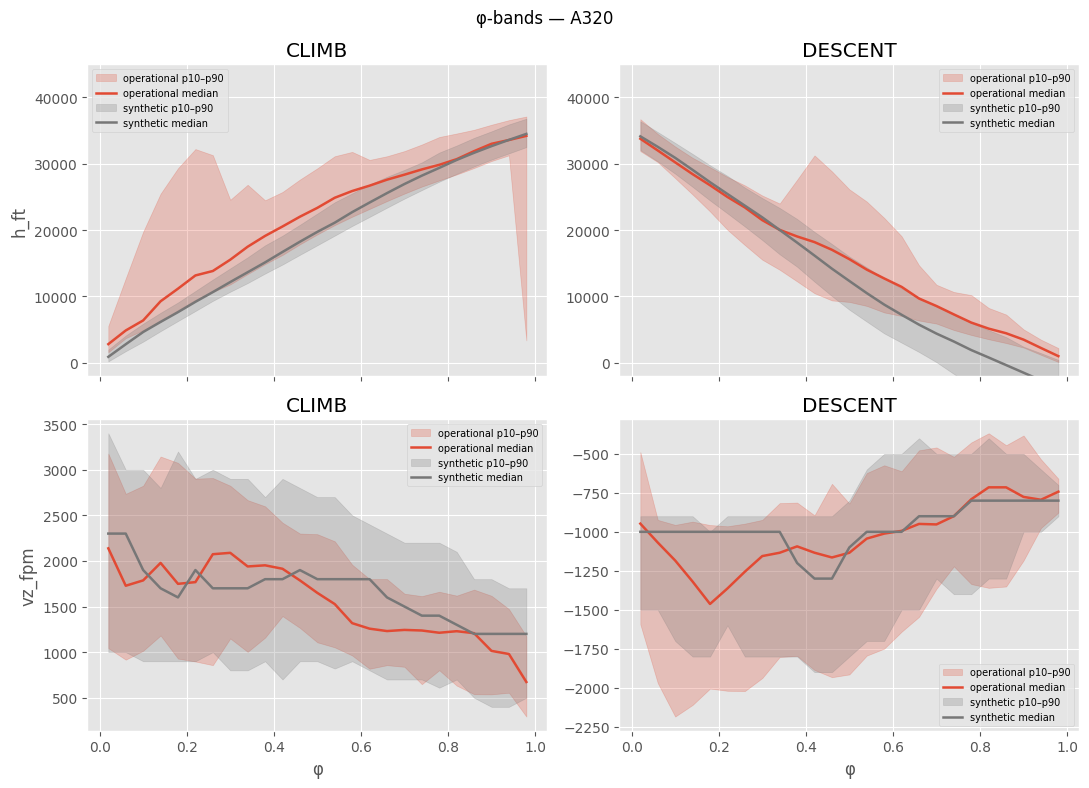

Synthetic LEVEL h_ft: >45k ft 0.0 | <0 ft 0.0


In [10]:
def attach_phi_within_phases(g):
    m = g.sort_values('timestamp').copy()
    m['phi'] = np.nan
    for phname in ('CLIMB', 'DESCENT'):
        mask = m['phase'].astype(str).str.upper() == phname
        if not mask.any():
            continue
        t0, t1 = m.loc[mask, 'timestamp'].iloc[0], m.loc[mask, 'timestamp'].iloc[-1]
        T = (t1 - t0).total_seconds()
        if T > 30:
            m.loc[mask, 'phi'] = (m.loc[mask, 'timestamp'] - t0).dt.total_seconds() / T
    return m


def enrich_pool_phi(prof, *, synthetic=False):
    parts = []
    key = ['draw_id'] if synthetic else ['route', 'flight_id']
    for _, g in prof.groupby(key, sort=False):
        parts.append(attach_phi_within_phases(g))
    return pd.concat(parts, ignore_index=True)


def phi_percentile_bands(long_df, phase, col, *, n_bins=25):
    d = long_df.loc[long_df['phase'] == phase].dropna(subset=['phi', col])
    if d.empty:
        return pd.DataFrame()
    edges = np.linspace(0, 1, n_bins + 1)
    d = d.copy()
    d['phi_bin'] = pd.cut(d['phi'], bins=edges, labels=False, include_lowest=True)
    rows = []
    for b, g in d.groupby('phi_bin', observed=True):
        y = g[col].to_numpy(dtype=float)
        rows.append({
            'phi': 0.5 * (edges[b] + edges[b + 1]),
            'p10': np.nanpercentile(y, 10),
            'p50': np.nanpercentile(y, 50),
            'p90': np.nanpercentile(y, 90),
        })
    return pd.DataFrame(rows)


def shade_band(ax, band, color, label):
    if band.empty:
        return
    ax.fill_between(band['phi'], band['p10'], band['p90'], color=color, alpha=0.25, label=label + ' p10–p90')
    ax.plot(band['phi'], band['p50'], color=color, lw=1.8, label=label + ' median')


ops_phi = enrich_pool_phi(operational_prof, synthetic=False)
syn_phi = enrich_pool_phi(synthetic_prof, synthetic=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex='col')
for j, phase in enumerate(['CLIMB', 'DESCENT']):
    for i, col in enumerate(['h_ft', 'vz_fpm']):
        ax = axes[i, j]
        shade_band(ax, phi_percentile_bands(ops_phi, phase, col), 'C0', 'operational')
        shade_band(ax, phi_percentile_bands(syn_phi, phase, col), 'C3', 'synthetic')
        if col == 'h_ft':
            ax.set_ylim(-2000, 45000)
        if i == 1:
            ax.set_xlabel('φ')
        if j == 0:
            ax.set_ylabel(col)
        ax.set_title(phase)
        ax.legend(fontsize=7, loc='best')
fig.suptitle(f'φ-bands — {TYPECODE}')
fig.tight_layout()
plt.show()

# tail diagnostic
syn_lvl = synthetic_prof[synthetic_prof['phase'] == 'LEVEL']['h_ft'].dropna()
if len(syn_lvl):
    print('Synthetic LEVEL h_ft: >45k ft', (syn_lvl > 45000).mean(), '| <0 ft', (syn_lvl < 0).mean())

## Full-flight vertical profile (time axis)

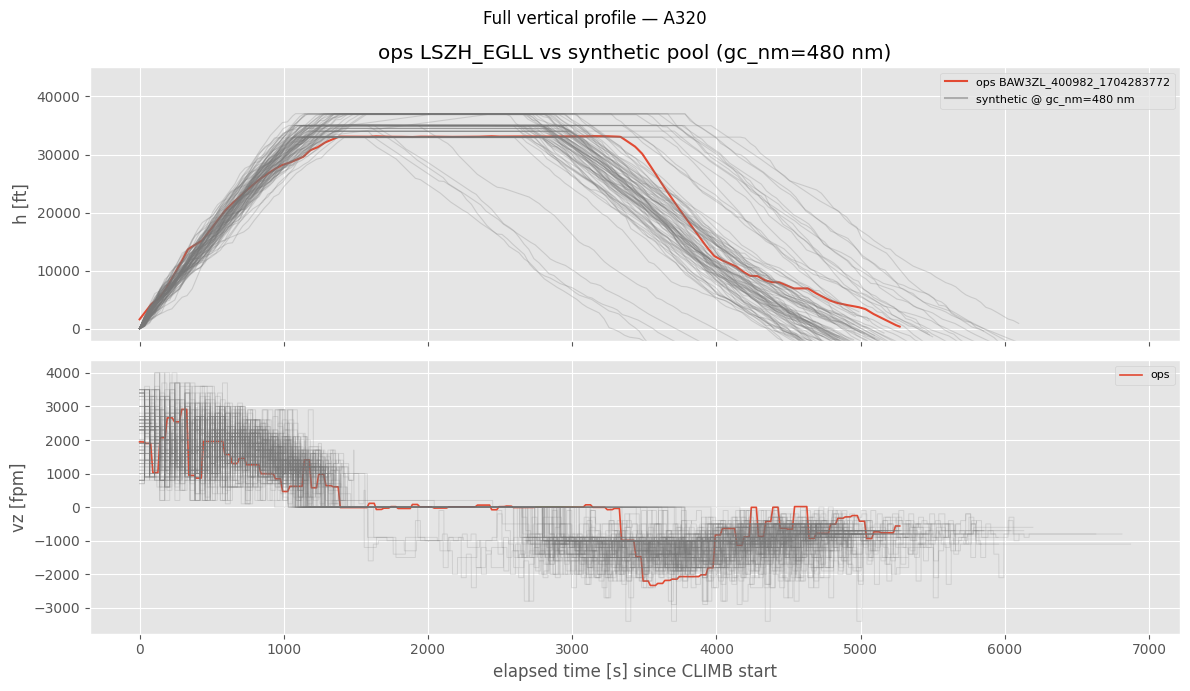

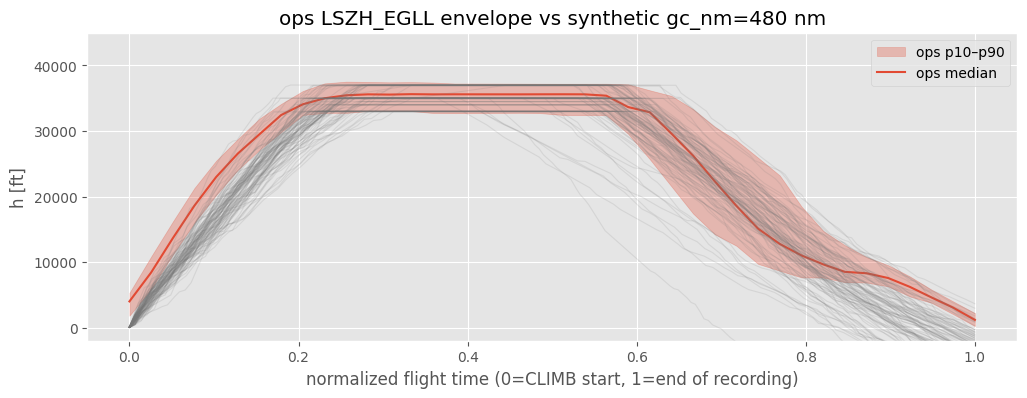

In [11]:
def add_elapsed_s(prof, *, group_cols):
    parts = []
    for _, g in prof.groupby(list(group_cols), sort=False):
        g = g.sort_values('timestamp').copy()
        t0 = pd.to_datetime(g['timestamp'].iloc[0], utc=True)
        g['t_s'] = (pd.to_datetime(g['timestamp'], utc=True) - t0).dt.total_seconds()
        parts.append(g)
    return pd.concat(parts, ignore_index=True)


ops_route = ROUTES[0]
ops_r = add_elapsed_s(
    operational_prof[operational_prof['route'] == ops_route],
    group_cols=['route', 'flight_id'],
)
syn_r = add_elapsed_s(synthetic_prof, group_cols=['draw_id'])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- altitude h(t) ---
ax = axes[0]
fid0 = ops_r['flight_id'].iloc[0]
one_ops = ops_r[ops_r['flight_id'] == fid0]
ax.plot(one_ops['t_s'], one_ops['h_ft'], color='C0', lw=1.5, label=f'ops {fid0}')
for gid, g in syn_r.groupby('draw_id'):
    ax.plot(g['t_s'], g['h_ft'], color='C3', alpha=0.25, lw=0.8)
ax.plot([], [], color='C3', alpha=0.5, label=f'synthetic @ gc_nm={GC_NM:.0f} nm')
ax.set_ylabel('h [ft]')
ax.set_title(f'ops {ops_route} vs synthetic pool (gc_nm={GC_NM:.0f} nm)')
ax.legend(loc='best', fontsize=8)
ax.set_ylim(-2000, 45000)

# --- vertical speed vz(t) ---
ax = axes[1]
ax.plot(one_ops['t_s'], one_ops['vz_fpm'], color='C0', lw=1.2, label='ops')
for gid, g in syn_r.groupby('draw_id'):
    ax.plot(g['t_s'], g['vz_fpm'], color='C3', alpha=0.2, lw=0.7)
ax.set_xlabel('elapsed time [s] since CLIMB start')
ax.set_ylabel('vz [fpm]')
ax.legend(loc='best', fontsize=8)

fig.suptitle(f'Full vertical profile — {TYPECODE}')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
norm_parts = []
for fid, g in ops_r.groupby('flight_id'):
    g = g.sort_values('t_s')
    T = g['t_s'].iloc[-1]
    if T < 60:
        continue
    gg = g.copy()
    gg['t_norm'] = g['t_s'] / T
    norm_parts.append(gg[['t_norm', 'h_ft']])
if norm_parts:
    long = pd.concat(norm_parts)
    long['t_bin'] = pd.cut(long['t_norm'], np.linspace(0, 1, 41), labels=False, include_lowest=True)
    band = (
        long.groupby('t_bin', observed=True)['h_ft']
        .quantile([0.1, 0.5, 0.9])
        .unstack(level=1)
    )
    band.columns = ['p10', 'p50', 'p90']
    x = np.linspace(0, 1, len(band))
    ax.fill_between(x, band['p10'], band['p90'], color='C0', alpha=0.3, label='ops p10–p90')
    ax.plot(x, band['p50'], color='C0', lw=1.5, label='ops median')
for gid, g in syn_r.groupby('draw_id'):
    g = g.sort_values('t_s')
    T = g['t_s'].iloc[-1]
    if T < 60:
        continue
    ax.plot(g['t_s'] / T, g['h_ft'], color='C3', alpha=0.15, lw=0.8)
ax.set_xlabel('normalized flight time (0=CLIMB start, 1=end of recording)')
ax.set_ylabel('h [ft]')
ax.set_ylim(-2000, 45000)
ax.legend()
ax.set_title(f'ops {ops_route} envelope vs synthetic gc_nm={GC_NM:.0f} nm')
plt.show()

## Fleet median h(φ) in DESCENT

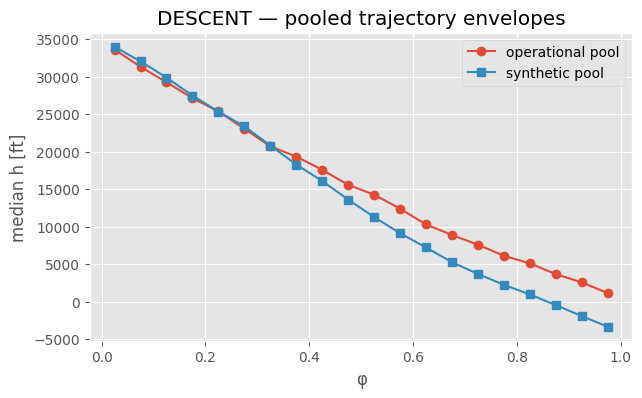

In [12]:
PHI_BINS = 20
edges = np.linspace(0, 1, PHI_BINS + 1)

def phi_binned_median_ops(prof):
    parts = []
    for (_, _), g in prof.groupby(['route', 'flight_id']):
        g = attach_phi_within_phases(g)
        d = g[g['phase'] == 'DESCENT'].dropna(subset=['phi', 'h_ft'])
        if d.empty:
            continue
        d = d.copy()
        d['phi_bin'] = pd.cut(d['phi'], bins=edges, labels=False, include_lowest=True)
        parts.append(d.groupby('phi_bin', observed=True)['h_ft'].median())
    return pd.concat(parts, axis=1).median(axis=1) if parts else pd.Series(dtype=float)

def phi_binned_median_syn(prof):
    parts = []
    for _, g in prof.groupby(['draw_id'], sort=False):
        g = attach_phi_within_phases(g)
        d = g[g['phase'] == 'DESCENT'].dropna(subset=['phi', 'h_ft'])
        if d.empty:
            continue
        d = d.copy()
        d['phi_bin'] = pd.cut(d['phi'], bins=edges, labels=False, include_lowest=True)
        parts.append(d.groupby('phi_bin', observed=True)['h_ft'].median())
    return pd.concat(parts, axis=1).median(axis=1) if parts else pd.Series(dtype=float)

xc = 0.5 * (edges[:-1] + edges[1:])
med_ops = phi_binned_median_ops(operational_prof)
med_syn = phi_binned_median_syn(synthetic_prof)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xc[: len(med_ops)], med_ops.values, 'o-', label='operational pool')
ax.plot(xc[: len(med_syn)], med_syn.values, 's-', label='synthetic pool')
ax.set_xlabel('φ'); ax.set_ylabel('median h [ft]'); ax.legend()
ax.set_title('DESCENT — pooled trajectory envelopes')
plt.show()

## KS on pooled trajectories

In [13]:
rows = []
for phase in ['CLIMB', 'DESCENT', 'LEVEL']:
    m = operational_prof['phase'] == phase
    n = synthetic_prof['phase'] == phase
    for col in ['h_ft', 'gamma_deg', 'tas_kt']:
        a = operational_prof.loc[m, col].dropna()
        b = synthetic_prof.loc[n, col].dropna()
        if len(a) < 50 or len(b) < 50:
            continue
        stat, p = sp_stats.ks_2samp(a, b)
        rows.append({'phase': phase, 'col': col, 'ks': stat, 'p': p})
display(pd.DataFrame(rows))

,phase,col,ks,p
0,CLIMB,h_ft,0.056382,1.185390e-130
1,CLIMB,gamma_deg,0.043339,2.388548e-77
2,CLIMB,tas_kt,0.084613,5.880359e-294
3,DESCENT,h_ft,0.160490,0.000000e+00
4,DESCENT,gamma_deg,0.075858,0.000000e+00
5,DESCENT,tas_kt,0.073117,0.000000e+00
6,LEVEL,h_ft,0.342349,0.000000e+00
7,LEVEL,gamma_deg,0.524326,0.000000e+00
8,LEVEL,tas_kt,0.163853,0.000000e+00
